# UBS Algo Quant — IS Slippage Analysis
**Author:** Xuzhou Wang


This notebook analyses the execution performance of two trading algorithms (`algo_1` vs `algo_2`) using IS Slippage (Arrival Slippage) as the primary metric.

$$\text{IS\_Slippage} = 10000 \times \text{side} \times \frac{\text{Execution Price} - \text{Arrival Mid Price}}{\text{Arrival Mid Price}} \quad (\text{in bps})$$



## 0. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import HuberRegressor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('LightGBM / SHAP not installed — Q7 will be skipped. Run: pip install lightgbm shap')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
COLORS = {'algo_1': '#2196F3', 'algo_2': '#FF5722'}
OUT_DIR = r'C:\Users\Colar\Desktop\UBS ALGO QUANT\answer\\'

# Load data
DATA_PATH = r'C:\Users\Colar\Desktop\UBS ALGO QUANT\IS_slippage_analysis\TCA_problem.csv'
df_raw = pd.read_csv(DATA_PATH, index_col=0)

print('Shape:', df_raw.shape)
print('Missing values:', df_raw.isnull().sum().to_dict())
print('Orders per algo:')
print(df_raw['algo'].value_counts())
df_raw.describe().round(2)

Shape: (40000, 7)
Missing values: {'IS_Slippage': 0, 'ordersize': 0, 'volatility': 0, 'averageSpread': 0, 'duration': 0, 'notional': 0, 'algo': 0}
Orders per algo:
algo_2    20000
algo_1    20000
Name: algo, dtype: int64


,IS_Slippage,ordersize,volatility,averageSpread,duration,notional
count,40000.00,40000.00,40000.00,40000.00,40000.00,4.000000e+04
mean,223.88,72.10,199.98,4.43,0.70,3.434024e+07
std,197.74,114.59,70.69,5.73,0.27,1.173464e+08
min,-450.98,0.46,100.00,0.05,0.00,8.166798e+04
25%,93.52,16.66,150.00,1.37,0.52,1.023405e+07
50%,187.26,36.79,200.00,2.71,0.77,2.027968e+07
75%,319.00,82.28,250.00,5.24,0.94,3.968378e+07
max,2433.72,3286.61,300.00,172.03,1.00,1.368619e+10


## 0.1 — Outlier Treatment: Winsorization

**Why this matters:**  
Real TCA data is extremely fat-tailed. Even 10 orders with IS Slippage of 5000+ bps (from fat-finger errors or black-swan events) can severely bias OLS coefficients — including the critical algo dummy $\beta_5$. Note: HC3 robust standard errors correct for **heteroskedasticity**, but do **not** protect against extreme leverage points (outliers with unusual feature values).

**Solution — Winsorization at 1%/99%:**  
We cap IS_Slippage and all features at their 1st and 99th percentiles. This is industry-standard practice in TCA. We preserve the raw data in `df_raw` for reference.

=== Winsorization Report (1% / 99%) ===
                   P1     P99  N_clipped
Column                                  
IS_Slippage   -129.05  853.19        800
ordersize        2.51  524.60        800
volatility     100.00  300.00          0
averageSpread    0.27   27.53        800
duration         0.03    1.00        400


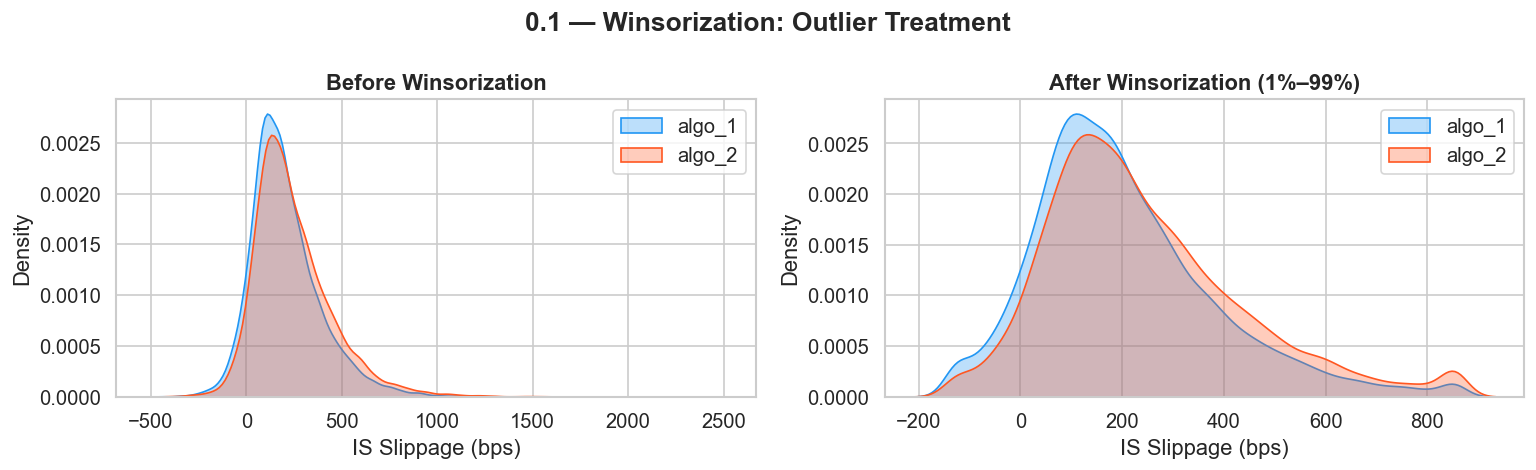

In [2]:
df = df_raw.copy()
WINSOR_COLS = ['IS_Slippage', 'ordersize', 'volatility', 'averageSpread', 'duration']

winsor_report = []
for col in WINSOR_COLS:
    lo, hi = df[col].quantile([0.01, 0.99])
    n_clipped = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    winsor_report.append({'Column': col, 'P1': lo, 'P99': hi, 'N_clipped': n_clipped})

winsor_df = pd.DataFrame(winsor_report).set_index('Column')
print('=== Winsorization Report (1% / 99%) ===')
print(winsor_df.round(2))

# Visual: IS Slippage before vs after winsorization
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, data, title in zip(axes,
    [df_raw['IS_Slippage'], df['IS_Slippage']],
    ['Before Winsorization', 'After Winsorization (1%–99%)']):
    for algo, color in COLORS.items():
        sns.kdeplot(data[df_raw['algo'] == algo], ax=ax, color=color,
                    label=algo, fill=True, alpha=0.3)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('IS Slippage (bps)')
    ax.legend()
plt.suptitle('0.1 — Winsorization: Outlier Treatment', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'q0_winsorization.png', bbox_inches='tight')
plt.show()

FEATURES = ['volatility', 'averageSpread', 'ordersize', 'duration']
is1 = df.loc[df['algo'] == 'algo_1', 'IS_Slippage'].values
is2 = df.loc[df['algo'] == 'algo_2', 'IS_Slippage'].values

## Q1 — Comparing IS Slippage of algo_1 vs algo_2

**Written Answer:**

At first glance, `algo_1` has a lower simple mean IS Slippage (~204 bps) vs `algo_2` (~244 bps), suggesting algo_1 executes with less market impact. However, a raw mean comparison is **not a fair judgment** — it ignores that the two algorithms may have been assigned orders with systematically different difficulty (e.g., algo_2 may handle larger, more volatile orders: a confounding variable problem). We first confirm statistical significance of the raw difference, then expose the confounding problem in Q3, and resolve it definitively in Q5.

**Three questions answered:**
1. *How to compare?* — Statistical tests (Welch t-test, Mann-Whitney U) + distribution visualisations (Violin, ECDF, KDE).
2. *Which performs better on raw numbers?* — `algo_1` has significantly lower mean IS Slippage.
3. *Why?* — Likely a mix of genuine outperformance AND selection bias from order routing. Q5 disentangles the two.

In [3]:
# --- Statistical Tests ---
t_stat, p_welch = stats.ttest_ind(is1, is2, equal_var=False)
u_stat, p_mwu   = stats.mannwhitneyu(is1, is2, alternative='two-sided')
pooled_std = np.sqrt((is1.std()**2 + is2.std()**2) / 2)
cohens_d   = (is1.mean() - is2.mean()) / pooled_std

np.random.seed(42)
boot_diffs = [
    np.random.choice(is1, len(is1), replace=True).mean() -
    np.random.choice(is2, len(is2), replace=True).mean()
    for _ in range(10_000)
]
boot_ci = np.percentile(boot_diffs, [2.5, 97.5])

print('=== Q1 Statistical Tests (on winsorized data) ===')
print(f'algo_1  mean={is1.mean():.2f} bps  median={np.median(is1):.2f} bps  std={is1.std():.2f}')
print(f'algo_2  mean={is2.mean():.2f} bps  median={np.median(is2):.2f} bps  std={is2.std():.2f}')
print(f'\nWelch t-test:    t={t_stat:.3f},  p={p_welch:.2e}')
print(f'Mann-Whitney U:  U={u_stat:.0f},  p={p_mwu:.2e}')
print(f"Cohen's d:       {cohens_d:.4f}  (|d|<0.2=small, 0.5=medium, 0.8=large)")
print(f'Bootstrap 95% CI on (mean1 - mean2): [{boot_ci[0]:.2f}, {boot_ci[1]:.2f}] bps')

=== Q1 Statistical Tests (on winsorized data) ===
algo_1  mean=203.71 bps  median=172.71 bps  std=179.36
algo_2  mean=241.76 bps  median=203.40 bps  std=194.42

Welch t-test:    t=-20.346,  p=1.48e-91
Mann-Whitney U:  U=177238242,  p=1.70e-86
Cohen's d:       -0.2035  (|d|<0.2=small, 0.5=medium, 0.8=large)
Bootstrap 95% CI on (mean1 - mean2): [-41.78, -34.33] bps


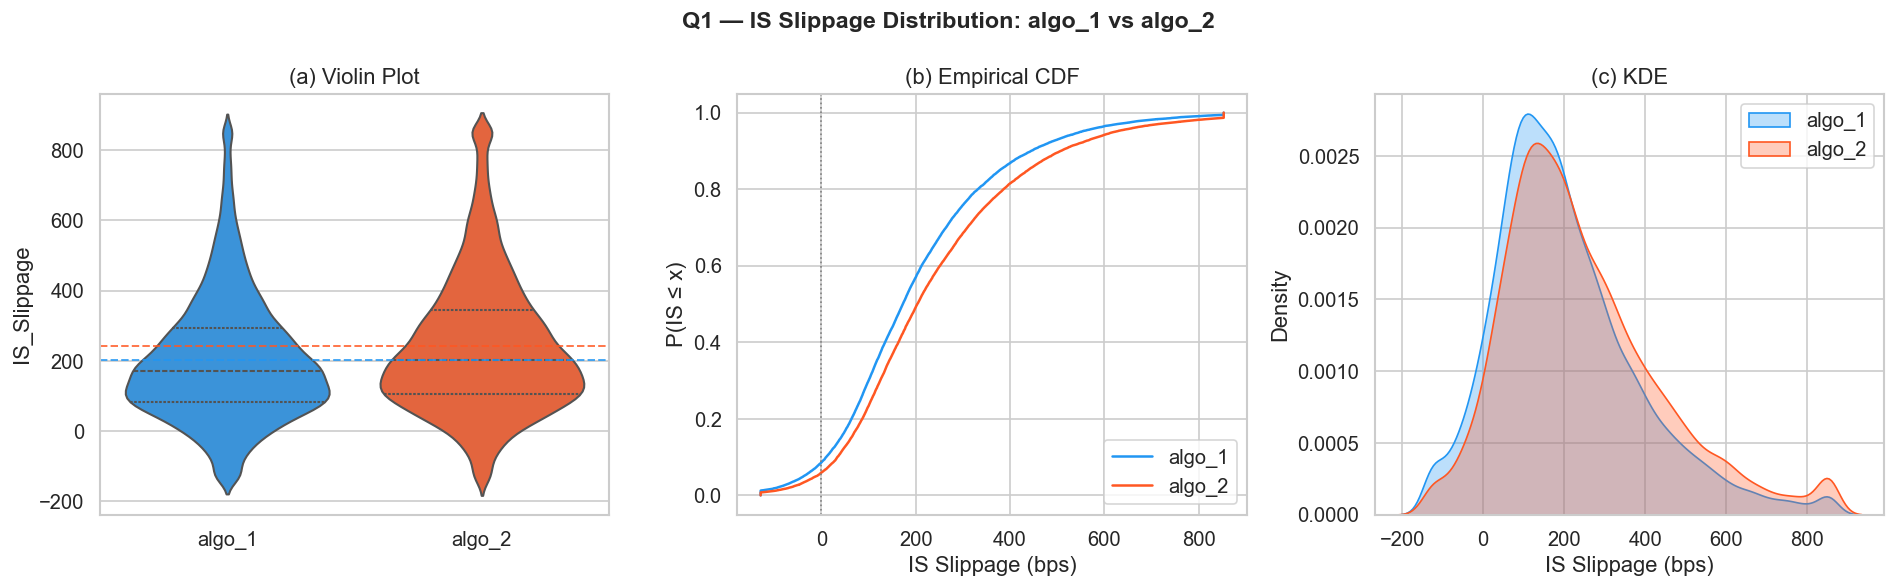

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Q1 — IS Slippage Distribution: algo_1 vs algo_2', fontsize=14, fontweight='bold')

# (a) Violin
sns.violinplot(data=df, x='algo', y='IS_Slippage', palette=COLORS,
               inner='quartile', ax=axes[0], order=['algo_1', 'algo_2'])
axes[0].set_title('(a) Violin Plot'); axes[0].set_xlabel('')
for algo, color in COLORS.items():
    axes[0].axhline(df.loc[df['algo']==algo,'IS_Slippage'].mean(),
                    color=color, linestyle='--', linewidth=1.2, alpha=0.8)

# (b) ECDF
for algo, color in COLORS.items():
    x = np.sort(df.loc[df['algo']==algo, 'IS_Slippage'].values)
    axes[1].plot(x, np.arange(1, len(x)+1)/len(x), color=color, label=algo, linewidth=1.5)
axes[1].set_title('(b) Empirical CDF')
axes[1].set_xlabel('IS Slippage (bps)'); axes[1].set_ylabel('P(IS ≤ x)')
axes[1].axvline(0, color='gray', linestyle=':', linewidth=1); axes[1].legend()

# (c) KDE
for algo, color in COLORS.items():
    sns.kdeplot(df.loc[df['algo']==algo,'IS_Slippage'],
                color=color, label=algo, fill=True, alpha=0.3, ax=axes[2])
axes[2].set_title('(c) KDE'); axes[2].set_xlabel('IS Slippage (bps)'); axes[2].legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'q1_distribution.png', bbox_inches='tight')
plt.show()

## Q2 — Notional-Weighted IS Slippage

**Written Answer:**

$$\text{NW\_IS} = \frac{\sum_i \text{IS}_i \times \text{notional}_i}{\sum_i \text{notional}_i}$$

**Interpretation:** Simple mean weights every order equally regardless of size. The notional-weighted IS reflects the **true dollar-impact on the portfolio** — the average slippage a Portfolio Manager (PM) actually experiences on each unit of capital deployed. It maps directly to fund P&L.

**Economic interpretation:** If NW_IS = 200 bps for algo_1, then for every CNY 10,000 traded, CNY 20 is lost to market impact and execution friction.

**Single order contribution:**
$$c_i = \text{IS}_i \times w_i, \quad w_i = \frac{\text{notional}_i}{\sum_j \text{notional}_j}$$
All contributions sum to NW_IS, enabling order-level attribution analysis.

=== Q2 Notional-Weighted IS Slippage ===

algo_1:
  Simple mean IS:           203.71 bps
  Notional-weighted IS:     206.90 bps  (diff: +3.19)
  Top 10% orders by notional drive 38.9% of total NW cost

algo_2:
  Simple mean IS:           241.76 bps
  Notional-weighted IS:     278.42 bps  (diff: +36.65)
  Top 10% orders by notional drive 50.2% of total NW cost


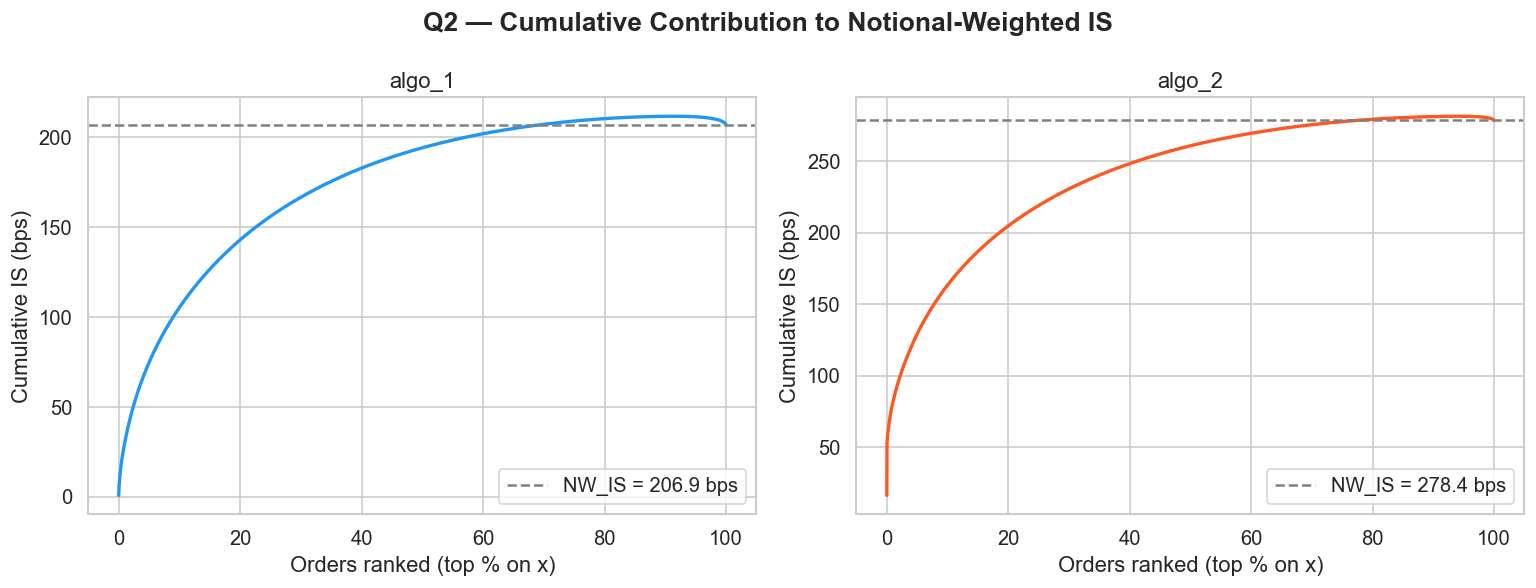

In [5]:
results_q2 = {}
for algo in ['algo_1', 'algo_2']:
    sub = df[df['algo'] == algo].copy()
    total_notional = sub['notional'].sum()
    nw_is = np.average(sub['IS_Slippage'], weights=sub['notional'])
    sub['weight']       = sub['notional'] / total_notional
    sub['contribution'] = sub['IS_Slippage'] * sub['weight']
    results_q2[algo] = {'df': sub, 'nw_is': nw_is, 'total_notional': total_notional}

print('=== Q2 Notional-Weighted IS Slippage ===')
for algo, res in results_q2.items():
    simple = df.loc[df['algo']==algo,'IS_Slippage'].mean()
    top10  = res['df'].nlargest(int(len(res['df'])*0.1),'notional')
    pct    = top10['contribution'].sum() / res['nw_is'] * 100
    print(f'\n{algo}:')
    print(f'  Simple mean IS:           {simple:.2f} bps')
    print(f'  Notional-weighted IS:     {res["nw_is"]:.2f} bps  (diff: {res["nw_is"]-simple:+.2f})')
    print(f'  Top 10% orders by notional drive {pct:.1f}% of total NW cost')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q2 — Cumulative Contribution to Notional-Weighted IS', fontweight='bold')
for ax, (algo, res) in zip(axes, results_q2.items()):
    sub = res['df'].sort_values('contribution', ascending=False).reset_index(drop=True)
    ax.plot(np.arange(1,len(sub)+1)/len(sub)*100, sub['contribution'].cumsum(),
            color=COLORS[algo], linewidth=2)
    ax.axhline(res['nw_is'], color='gray', linestyle='--', label=f'NW_IS = {res["nw_is"]:.1f} bps')
    ax.set_title(algo); ax.set_xlabel('Orders ranked (top % on x)'); ax.set_ylabel('Cumulative IS (bps)')
    ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'q2_contribution.png', bbox_inches='tight')
plt.show()

## Q3 — Distribution of Features + POV Proxy Feature Engineering

**Written Answer:**

I examine four raw features plus one engineered feature:

- **volatility** / **averageSpread** / **ordersize**: Expected right-skewed — most orders occur in normal conditions, a few in extreme ones.
- **duration**: Possibly bimodal — some orders are brief; others run the full trading day.
- **Execution_Intensity = ordersize / duration** *(new)*: This is a proxy for **Percentage-of-Volume (POV) rate** — how aggressively the algorithm trades relative to market volume per unit time. In execution research, slippage depends not just on order size but on *how fast* you force the market to absorb it. A large order spread over a full day has far lower impact than the same order hammered through in 30 minutes.

We split all distributions by algo to check for **confounding variables** (if algo_2 systematically receives harder orders, the Q1 comparison is invalid).

In [6]:
# --- POV Proxy: Execution Intensity ---
df['exec_intensity'] = df['ordersize'] / df['duration'].clip(lower=1e-4)
print('Execution Intensity (ordersize / duration) stats:')
print(df.groupby('algo')['exec_intensity'].describe().round(2))

ALL_FEATURES = ['volatility', 'averageSpread', 'ordersize', 'duration', 'exec_intensity']

# Summary stats table
rows = []
for feat in ALL_FEATURES:
    for algo in ['algo_1','algo_2']:
        s = df.loc[df['algo']==algo, feat]
        rows.append({'Feature':feat,'Algo':algo,'Mean':s.mean(),'Median':s.median(),
                     'Std':s.std(),'Skew':stats.skew(s),'P5':s.quantile(0.05),'P95':s.quantile(0.95)})
print('\n=== Feature Summary Statistics ===')
print(pd.DataFrame(rows).set_index(['Feature','Algo']).round(2).to_string())

Execution Intensity (ordersize / duration) stats:
          count    mean     std   min    25%     50%     75%       max
algo                                                                  
algo_1  20000.0   76.91  200.39  2.51  14.89   31.17   68.78   8024.39
algo_2  20000.0  247.31  648.06  2.51  48.90  103.56  229.24  15513.20

=== Feature Summary Statistics ===
                         Mean  Median     Std   Skew      P5     P95
Feature        Algo                                                 
volatility     algo_1  199.36  200.00   70.72   0.02  100.00  300.00
               algo_2  200.61  200.00   70.66  -0.01  100.00  300.00
averageSpread  algo_1    4.30    2.71    4.73   2.53    0.53   13.95
               algo_2    4.31    2.71    4.79   2.57    0.53   14.13
ordersize      algo_1   33.42   20.56   41.46   4.14    3.91  106.62
               algo_2  104.85   67.06  109.13   2.08   13.02  351.95
duration       algo_1    0.70    0.77    0.27  -0.78    0.16    1.00
         

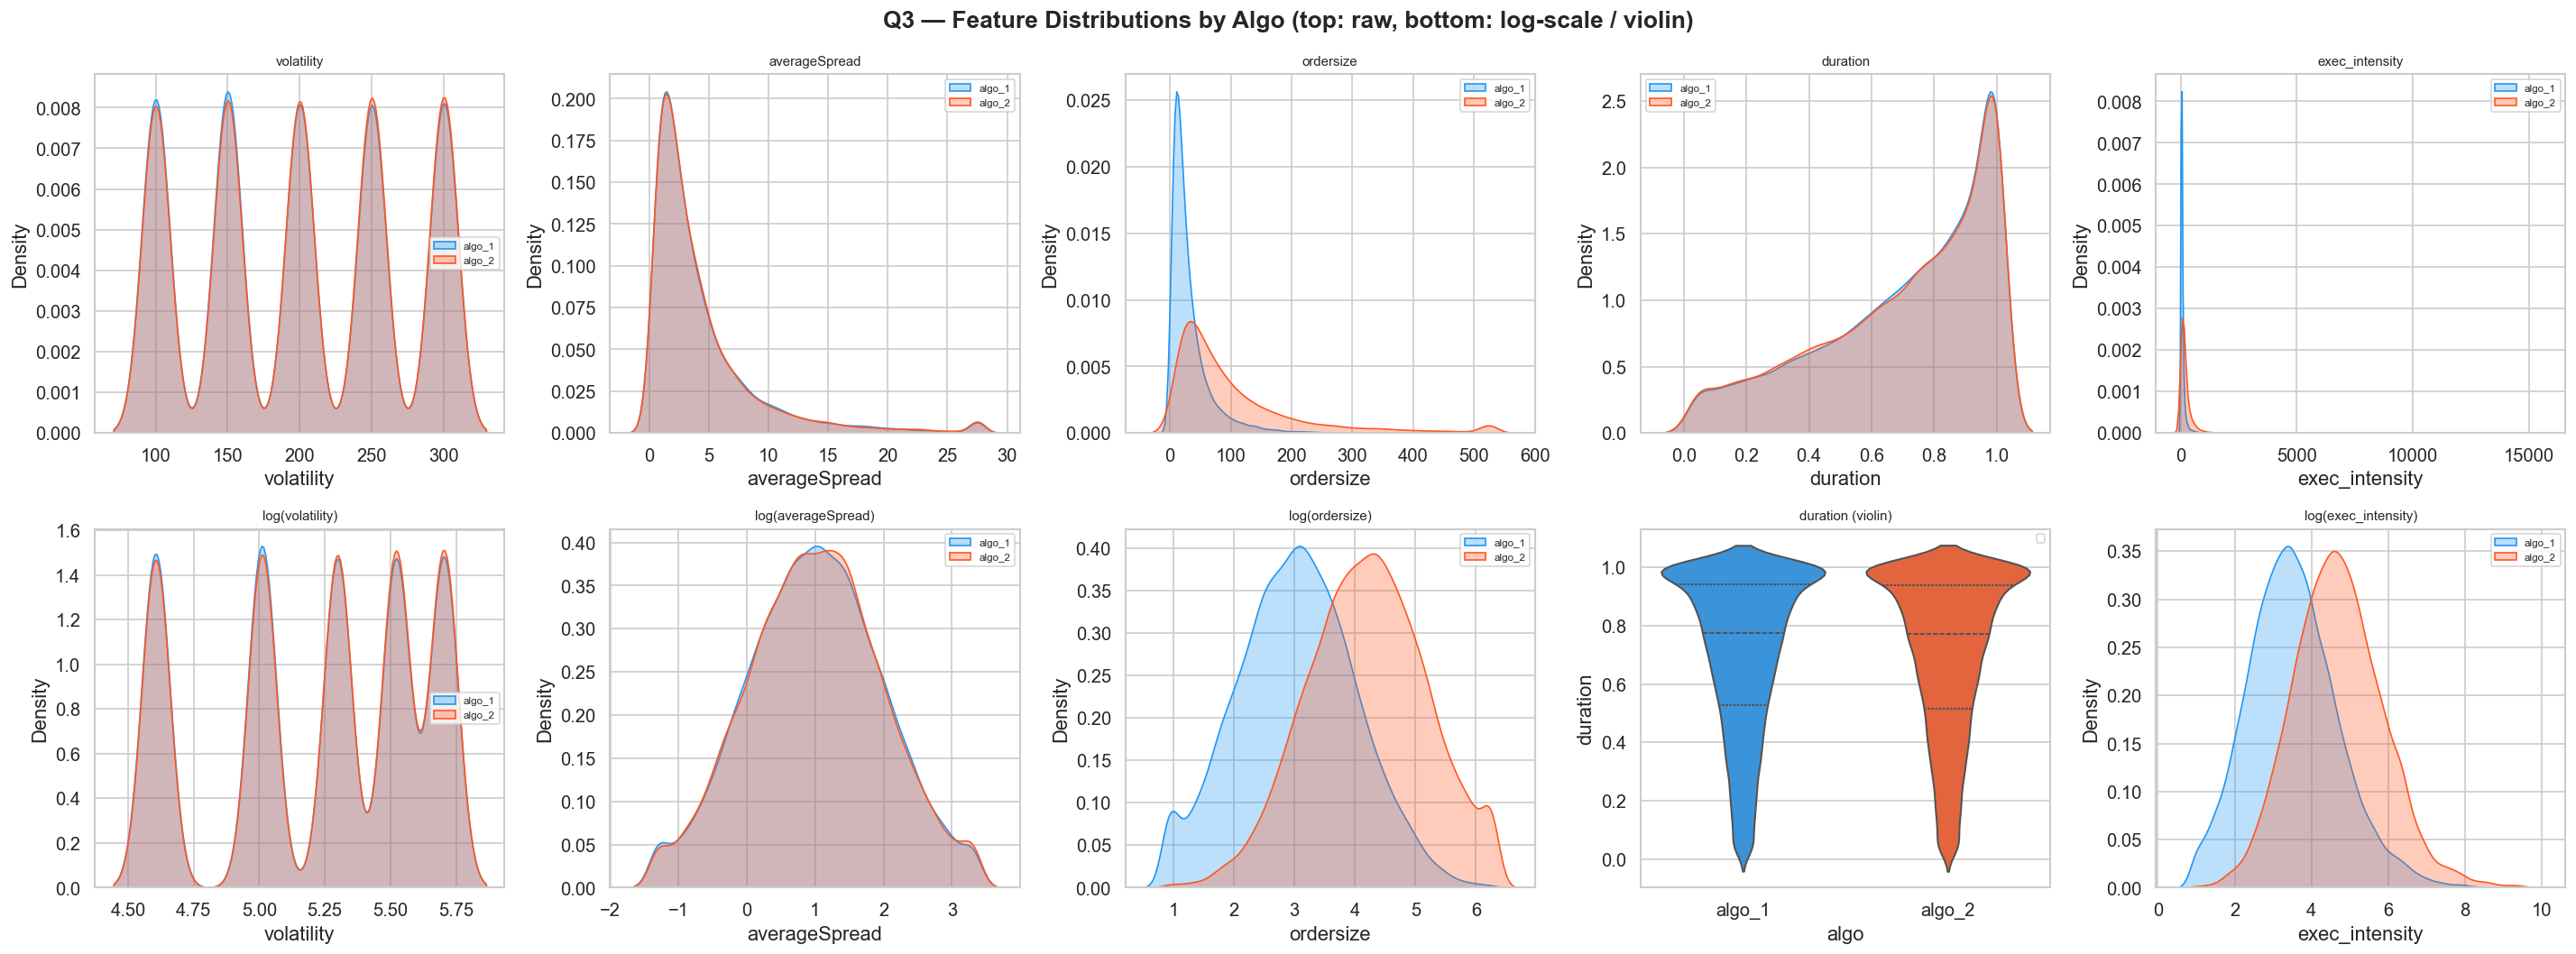

=== KS test: same feature distribution across algos? ===
  volatility          : KS=0.0096, p=0.3194     ok
  averageSpread       : KS=0.0063, p=0.8198     ok
  ordersize           : KS=0.4466, p=0.0000  *** CONFOUNDING VARIABLE DETECTED
  duration            : KS=0.0088, p=0.4185     ok
  exec_intensity      : KS=0.4052, p=0.0000  *** CONFOUNDING VARIABLE DETECTED


In [7]:
# --- Distribution plots ---
log_feats = ['volatility', 'averageSpread', 'ordersize', 'exec_intensity']
fig, axes = plt.subplots(2, 5, figsize=(24, 9))
fig.suptitle('Q3 — Feature Distributions by Algo (top: raw, bottom: log-scale / violin)', fontweight='bold')

for col, feat in enumerate(ALL_FEATURES):
    ax_top = axes[0, col]
    for algo, color in COLORS.items():
        sns.kdeplot(df.loc[df['algo']==algo, feat], ax=ax_top,
                    color=color, label=algo, fill=True, alpha=0.3)
    ax_top.set_title(feat, fontsize=9)
    ax_top.legend(fontsize=7)

    ax_bot = axes[1, col]
    if feat in log_feats:
        for algo, color in COLORS.items():
            vals = np.log(df.loc[df['algo']==algo, feat].clip(lower=1e-6))
            sns.kdeplot(vals, ax=ax_bot, color=color, label=algo, fill=True, alpha=0.3)
        ax_bot.set_title(f'log({feat})', fontsize=9)
    else:
        sns.violinplot(data=df, x='algo', y=feat, palette=COLORS,
                       inner='quartile', ax=ax_bot, order=['algo_1','algo_2'])
        ax_bot.set_title(f'{feat} (violin)', fontsize=9)
    ax_bot.legend(fontsize=7)

plt.tight_layout()
plt.savefig(OUT_DIR + 'q3_feature_distributions.png', bbox_inches='tight')
plt.show()

# KS test: are feature distributions different across algos?
print('=== KS test: same feature distribution across algos? ===')
for feat in ALL_FEATURES:
    ks, p = stats.ks_2samp(df.loc[df['algo']=='algo_1',feat], df.loc[df['algo']=='algo_2',feat])
    flag = '*** CONFOUNDING VARIABLE DETECTED' if p < 0.05 else '   ok'
    print(f'  {feat:<20}: KS={ks:.4f}, p={p:.4f}  {flag}')

## Q4 — Relationship Between Features and IS Slippage

**Written Answer:**

Based on market microstructure theory, we expect:
- **volatility ↑ → IS ↑**: Adverse selection costs increase in volatile markets.
- **averageSpread ↑ → IS ↑**: Wide spreads signal illiquid markets with higher impact.
- **ordersize ↑ → IS ↑**: The **Almgren-Chriss Square Root Law**: $\text{impact} \propto \sqrt{\text{ordersize}}$.
- **duration ↑ → IS ↓ (ambiguous)**: Spreading execution over time reduces instantaneous impact but increases timing risk.
- **exec_intensity ↑ → IS ↑**: Forcing the market to absorb high volume per unit time drives adverse price movement.

We use **Spearman rank correlation** (robust to non-linearity and heavy tails) and **LOWESS smoothing** to verify the functional form before model specification.

In [8]:
print('=== Q4 Spearman Rank Correlations with IS_Slippage ===')
print(f'{"Feature":<22} {"All":>8} {"algo_1":>8} {"algo_2":>8}')
print('-'*52)
for feat in ALL_FEATURES:
    rho_all,_ = stats.spearmanr(df[feat], df['IS_Slippage'])
    rho1,_    = stats.spearmanr(df.loc[df['algo']=='algo_1',feat], df.loc[df['algo']=='algo_1','IS_Slippage'])
    rho2,_    = stats.spearmanr(df.loc[df['algo']=='algo_2',feat], df.loc[df['algo']=='algo_2','IS_Slippage'])
    print(f'  {feat:<20} {rho_all:>+8.4f} {rho1:>+8.4f} {rho2:>+8.4f}')

=== Q4 Spearman Rank Correlations with IS_Slippage ===
Feature                     All   algo_1   algo_2
----------------------------------------------------
  volatility            +0.4129  +0.4008  +0.4274
  averageSpread         +0.0019  -0.0004  +0.0049
  ordersize             +0.5184  +0.5286  +0.5733
  duration              -0.0123  -0.0129  -0.0105
  exec_intensity        +0.4657  +0.4634  +0.4970


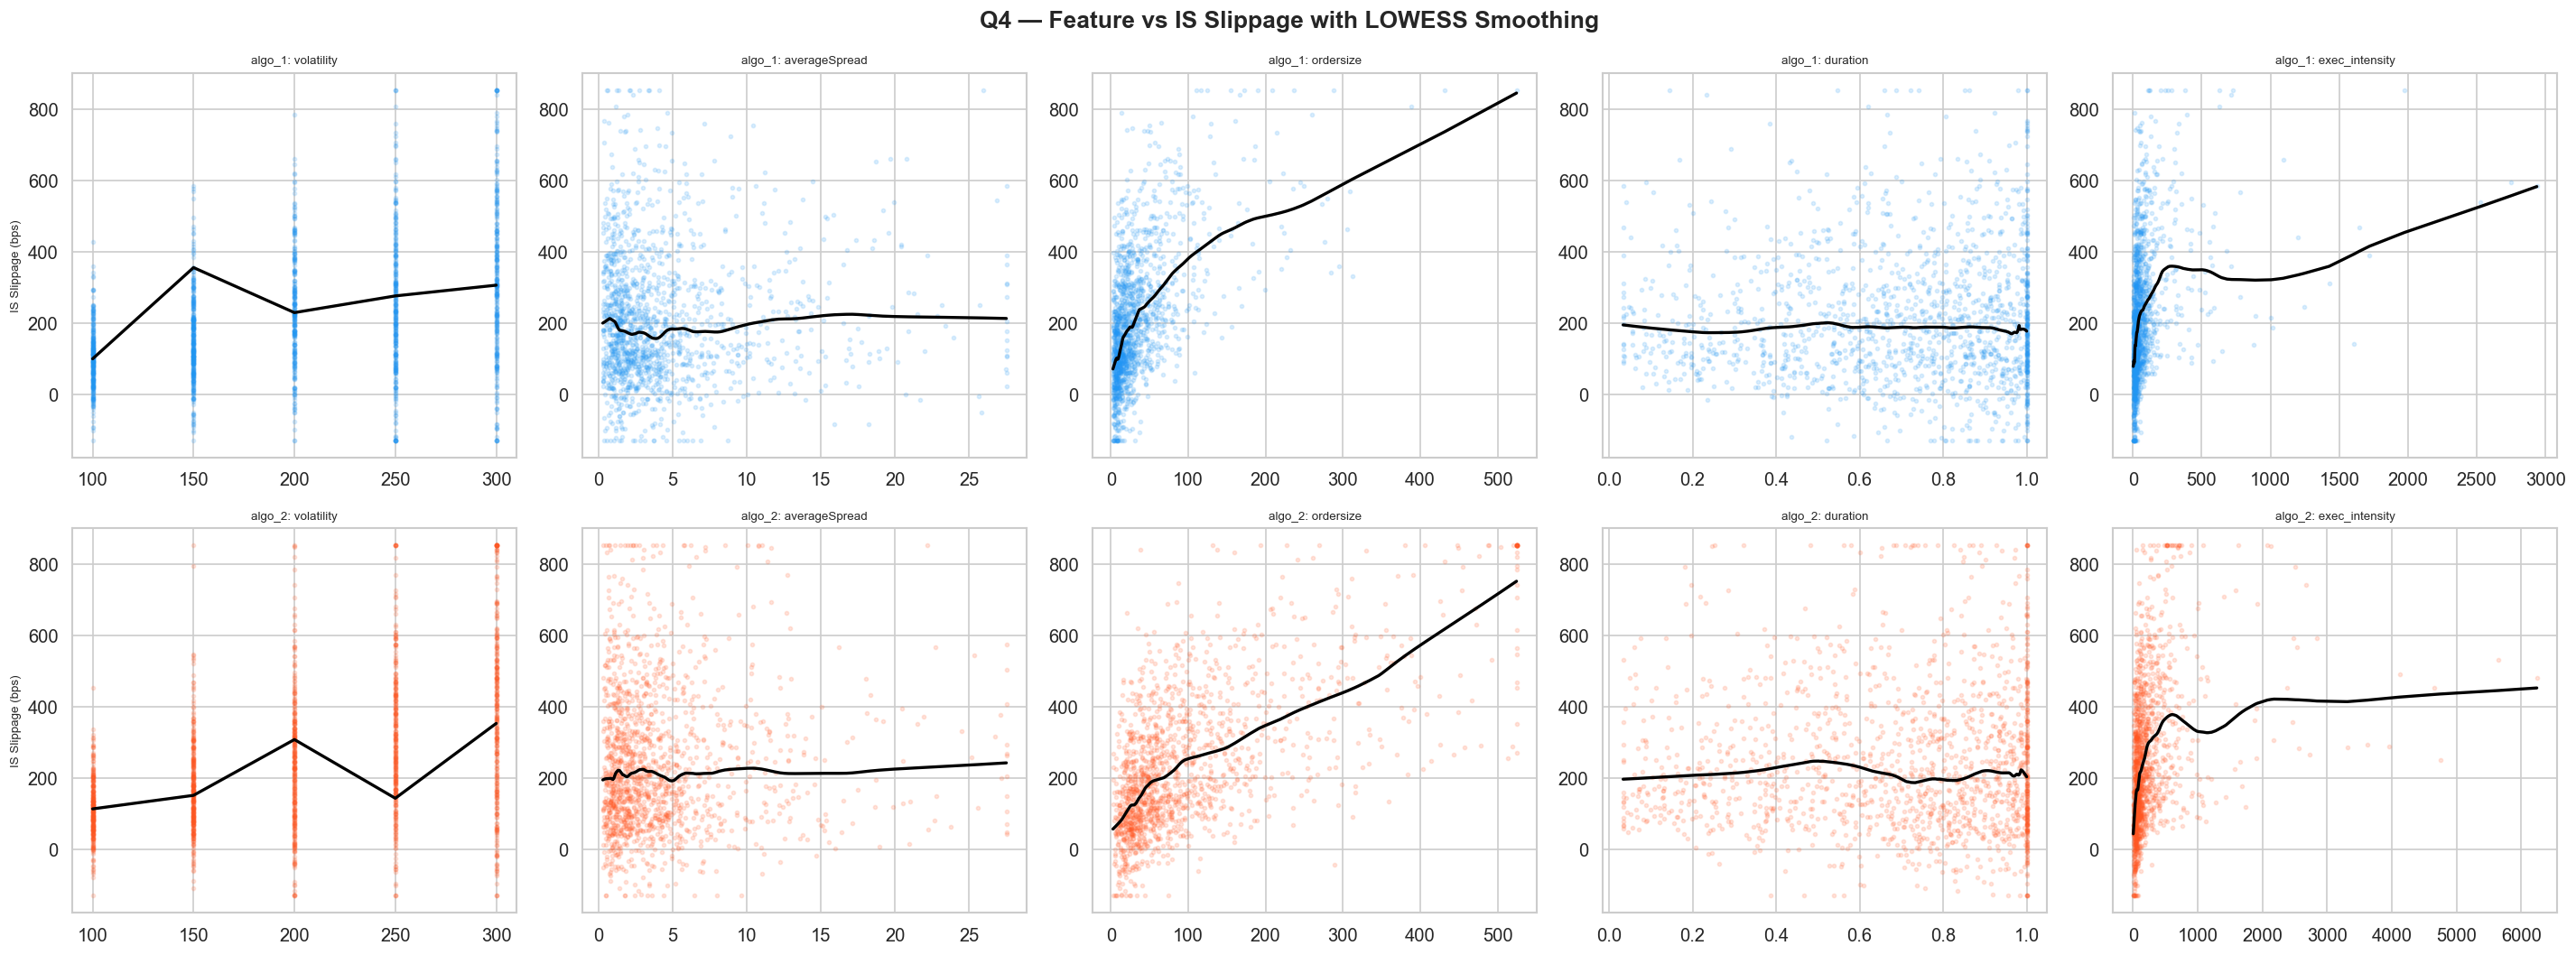

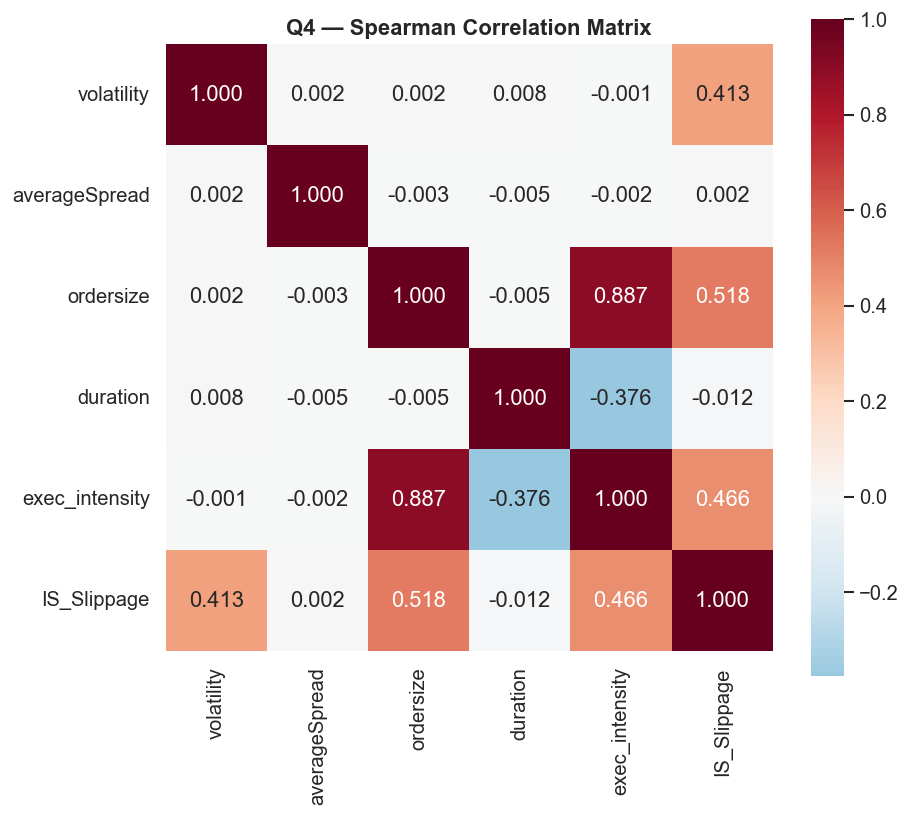

In [9]:
# Scatter + LOWESS
np.random.seed(0)

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
fig.suptitle('Q4 — Feature vs IS Slippage with LOWESS Smoothing', fontweight='bold')

for col, feat in enumerate(ALL_FEATURES):
    for row, algo in enumerate(['algo_1','algo_2']):
        ax = axes[row, col]
        sub_all = df[df['algo']==algo]          # ← 先过滤
        n = min(1500, len(sub_all))             # ← 再算 n
        sub = sub_all.sample(n, random_state=0) # ← 再采样
        ax.scatter(sub[feat], sub['IS_Slippage'], alpha=0.15, s=6, color=COLORS[algo])
        lw = lowess(sub.sort_values(feat)['IS_Slippage'], sub.sort_values(feat)[feat], frac=0.2)
        ax.plot(lw[:,0], lw[:,1], color='black', linewidth=2)
        ax.set_title(f'{algo}: {feat}', fontsize=8)
        if col == 0: ax.set_ylabel('IS Slippage (bps)', fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR + 'q4_scatter_lowess.png', bbox_inches='tight')
plt.show()

# Correlation heatmap
corr_cols = ALL_FEATURES + ['IS_Slippage']
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(df[corr_cols].corr(method='spearman'), annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, square=True, ax=ax)
ax.set_title('Q4 — Spearman Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'q4_correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Q5 — Model Fitting, Interpretation & Economic Significance

**Written Answer — Model Design:**

I incorporate three layers of sophistication:

**Layer 1 — Theory-driven feature transforms (Almgren-Chriss + log-linearity):**
- `log(volatility)`, `log(spread)`: linearise the right-skewed multiplicative relationship.
- `sqrt(ordersize)`: the **Square Root Law** — market impact $\propto \sqrt{\text{ordersize}}$, not linearly.
- `duration`: already in [0,1].
- `sqrt(exec_intensity)`: POV proxy transformed via sqrt for consistency with impact theory.

**Layer 2 — Interaction term (microstructure resonance):**
$$\text{Impact\_Multiplier} = \log(\text{spread}) \times \sqrt{\text{ordersize}}$$
This captures **double punishment**: pushing a large order through an illiquid (wide-spread) market is not just additive — the two effects amplify each other. Without this term, the model underestimates costs for the worst-case orders.

**Layer 3 — Robustness (HC3 + Huber Regression cross-check):**
HC3 robust standard errors handle heteroskedasticity. As a cross-validation, we also fit a **Huber Regressor** (robust to remaining outliers even after winsorization).

**The algo dummy $\beta_5$** is the definitive metric: algo_2's IS premium (in bps) over algo_1 on orders with *identical* market conditions.

In [10]:
# --- Feature Engineering ---
df['log_vol']        = np.log(df['volatility'].clip(lower=1e-6))
df['log_spread']     = np.log(df['averageSpread'].clip(lower=1e-6))
df['sqrt_size']      = np.sqrt(df['ordersize'].clip(lower=0))
df['sqrt_intensity'] = np.sqrt(df['exec_intensity'].clip(lower=0))
df['algo_dummy']     = (df['algo'] == 'algo_2').astype(int)

# Interaction term: log(spread) x sqrt(ordersize)
df['spread_x_size']  = df['log_spread'] * df['sqrt_size']

ENG_FEATURES = ['log_vol', 'log_spread', 'sqrt_size', 'duration', 'sqrt_intensity', 'spread_x_size']

# VIF check
X_vif = sm.add_constant(df[ENG_FEATURES])
vif_df = pd.DataFrame({'Feature': ENG_FEATURES,
    'VIF': [variance_inflation_factor(X_vif.values, i+1) for i in range(len(ENG_FEATURES))]})
print('=== Variance Inflation Factors (VIF) ===')
print(vif_df.round(2))
print('  Note: VIF > 10 = problematic multicollinearity. Interaction terms typically inflate VIF.')

=== Variance Inflation Factors (VIF) ===
          Feature   VIF
0         log_vol  1.00
1      log_spread  3.86
2       sqrt_size  3.96
3        duration  1.85
4  sqrt_intensity  3.83
5   spread_x_size  4.90
  Note: VIF > 10 = problematic multicollinearity. Interaction terms typically inflate VIF.


In [11]:
# --- Primary OLS with HC3 Robust Standard Errors ---
X = sm.add_constant(df[ENG_FEATURES + ['algo_dummy']])
y = df['IS_Slippage']

ols_model = sm.OLS(y, X).fit(cov_type='HC3')
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:            IS_Slippage   R-squared:                       0.527
Model:                            OLS   Adj. R-squared:                  0.527
Method:                 Least Squares   F-statistic:                     6293.
Date:                Thu, 26 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:56:17   Log-Likelihood:            -2.5125e+05
No. Observations:               40000   AIC:                         5.025e+05
Df Residuals:                   39992   BIC:                         5.026e+05
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const           -978.6940      8.845   -110.

In [12]:
# --- Breusch-Pagan heteroskedasticity test ---
ols_plain = sm.OLS(y, X).fit()
bp_stat, bp_p, _, _ = het_breuschpagan(ols_plain.resid, X)
print(f'Breusch-Pagan: stat={bp_stat:.3f}, p={bp_p:.4f}')
print('-> Heteroskedasticity detected — HC3 robust SEs are necessary.' if bp_p < 0.05
      else '-> No significant heteroskedasticity.')

Breusch-Pagan: stat=5167.356, p=0.0000
-> Heteroskedasticity detected — HC3 robust SEs are necessary.


In [13]:
# --- Huber Regression: Robustness Cross-Check ---
# Standardise features (Huber requires scaled inputs)
scaler = StandardScaler()
X_eng  = df[ENG_FEATURES + ['algo_dummy']].values
X_sc   = scaler.fit_transform(X_eng)

huber = HuberRegressor(epsilon=1.35, max_iter=500).fit(X_sc, y)
col_names = ENG_FEATURES + ['algo_dummy']

print('=== Huber Regression Coefficients (standardised features) ===')
print('  (Positive = increases IS slippage; negative = decreases)')
for name, coef in sorted(zip(col_names, huber.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {name:<22}: {coef:>+10.4f}')

# Sign agreement between OLS and Huber for algo_dummy
ols_b5    = ols_model.params['algo_dummy']
huber_b5  = huber.coef_[col_names.index('algo_dummy')]
sign_match = 'AGREE' if (ols_b5 > 0) == (huber_b5 > 0) else 'DISAGREE'
print(f'\nalgo_dummy sign: OLS={ols_b5:+.2f}  Huber={huber_b5:+.4f}  -> {sign_match}')
print('If both agree in direction, the algo_dummy result is robust to remaining outliers.')

=== Huber Regression Coefficients (standardised features) ===
  (Positive = increases IS slippage; negative = decreases)
  sqrt_size             :  +121.5783
  log_vol               :   +73.5151
  algo_dummy            :   -39.0919
  spread_x_size         :    +1.7902
  sqrt_intensity        :    -1.6915
  log_spread            :    -0.7155
  duration              :    -0.3909

algo_dummy sign: OLS=-83.58  Huber=-39.0919  -> AGREE
If both agree in direction, the algo_dummy result is robust to remaining outliers.


In [14]:
# --- Quantile Regression ---
formula = ('IS_Slippage ~ log_vol + log_spread + sqrt_size + duration + '
           'sqrt_intensity + spread_x_size + algo_dummy')
print('=== Quantile Regression: algo_dummy coefficient ===')
print(f'{"Quantile":<10} {"β₅ (bps)":>12} {"p-value":>12} {"95% CI":>25}')
print('-'*65)
qr_results = {}
for q in [0.10, 0.25, 0.50, 0.75, 0.90]:
    qr = smf.quantreg(formula, df).fit(q=q, max_iter=2000)
    b, p, ci = qr.params['algo_dummy'], qr.pvalues['algo_dummy'], qr.conf_int().loc['algo_dummy']
    qr_results[q] = {'beta': b, 'p': p, 'ci': ci}
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
    print(f'  Q{q:.0%}      {b:>+12.2f}   {p:>12.4f}   [{ci[0]:>8.2f}, {ci[1]:>8.2f}] {sig}')

print('\n  *** p<0.001')

=== Quantile Regression: algo_dummy coefficient ===
Quantile       β₅ (bps)      p-value                    95% CI
-----------------------------------------------------------------
  Q10%            -63.32         0.0000   [  -66.94,   -59.69] ***
  Q25%            -70.41         0.0000   [  -73.34,   -67.48] ***
  Q50%            -75.87         0.0000   [  -78.74,   -73.01] ***
  Q75%            -79.64         0.0000   [  -83.05,   -76.23] ***
  Q90%            -77.33         0.0000   [  -81.82,   -72.83] ***

  *** p<0.001


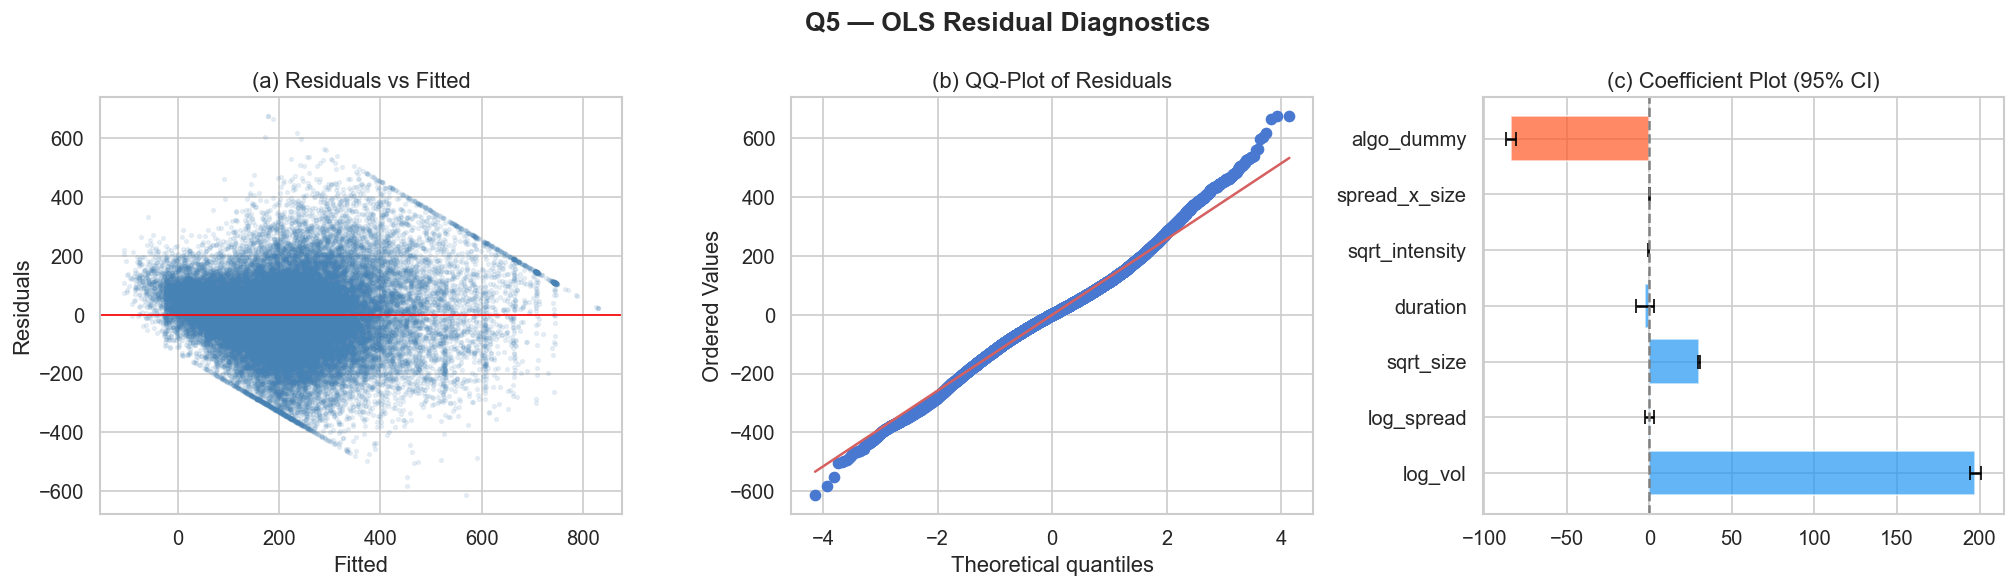

In [15]:
# --- Residual diagnostics + coefficient plot ---
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Q5 — OLS Residual Diagnostics', fontweight='bold')

resid, fitted = ols_plain.resid, ols_plain.fittedvalues

axes[0].scatter(fitted, resid, alpha=0.1, s=5, color='steelblue')
axes[0].axhline(0, color='red', linewidth=1)
axes[0].set_title('(a) Residuals vs Fitted'); axes[0].set_xlabel('Fitted'); axes[0].set_ylabel('Residuals')

stats.probplot(resid, dist='norm', plot=axes[1])
axes[1].set_title('(b) QQ-Plot of Residuals')

coefs = ols_model.params.drop('const')
cis   = ols_model.conf_int().drop('const')
bar_colors = ['#FF5722' if 'algo' in k else '#2196F3' for k in coefs.index]
axes[2].barh(coefs.index, coefs.values, color=bar_colors, alpha=0.7)
axes[2].errorbar(coefs.values, coefs.index,
                 xerr=[coefs - cis[0], cis[1] - coefs],
                 fmt='none', color='black', capsize=4)
axes[2].axvline(0, color='gray', linestyle='--')
axes[2].set_title('(c) Coefficient Plot (95% CI)')

plt.tight_layout()
plt.savefig(OUT_DIR + 'q5_diagnostics.png', bbox_inches='tight')
plt.show()

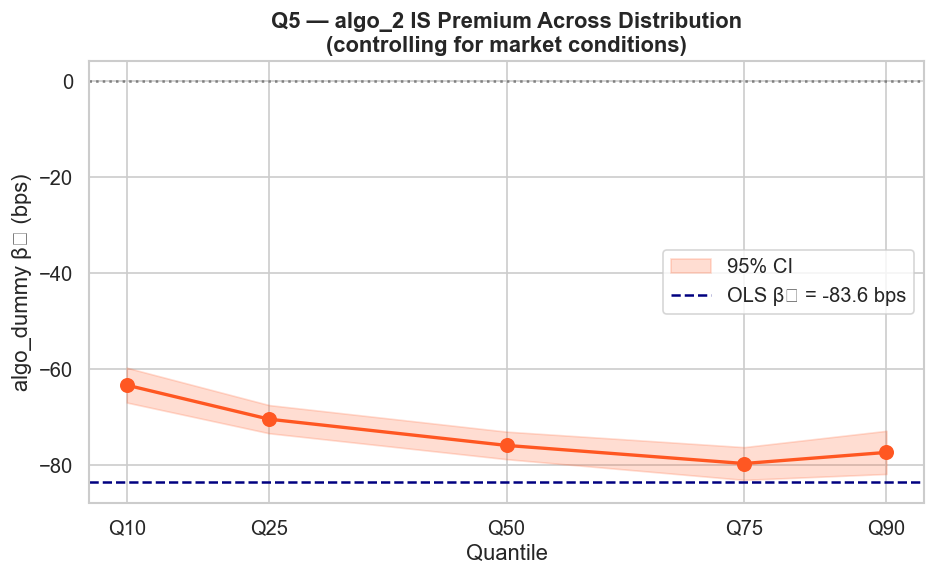

In [16]:
# Quantile regression plot
qs    = list(qr_results.keys())
betas = [qr_results[q]['beta'] for q in qs]
lo    = [qr_results[q]['ci'][0] for q in qs]
hi    = [qr_results[q]['ci'][1] for q in qs]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(qs, betas, 'o-', color='#FF5722', linewidth=2, markersize=8)
ax.fill_between(qs, lo, hi, alpha=0.2, color='#FF5722', label='95% CI')
ax.axhline(ols_model.params['algo_dummy'], color='navy', linestyle='--',
           label=f'OLS β₅ = {ols_model.params["algo_dummy"]:+.1f} bps')
ax.axhline(0, color='gray', linestyle=':')
ax.set_xlabel('Quantile'); ax.set_ylabel('algo_dummy β₅ (bps)')
ax.set_title('Q5 — algo_2 IS Premium Across Distribution\n(controlling for market conditions)', fontweight='bold')
ax.legend(); ax.set_xticks(qs); ax.set_xticklabels([f'Q{int(q*100)}' for q in qs])
plt.tight_layout()
plt.savefig(OUT_DIR + 'q5_quantile_regression.png', bbox_inches='tight')
plt.show()

### Q5 Conclusion — Statistical & Economic Significance

**Statistical conclusion:** The algo dummy $\beta_5$ tells us whether algo_2 costs more or less than algo_1, controlling for all market conditions. If $\beta_5 > 0$ and significant, algo_1 is the better algorithm on a like-for-like basis.

**Economic significance (P&L Impact):** Statistical significance alone is insufficient for a trading desk. We need to quantify the *dollar value* of the performance difference.

In [17]:
# --- Economic Significance: P&L Impact Calculation ---
b5    = ols_model.params['algo_dummy']
p5    = ols_model.pvalues['algo_dummy']
ci5   = ols_model.conf_int().loc['algo_dummy']

print('=== Q5 Final Verdict: Statistical Significance ===')
print(f'β₅ (algo_dummy) = {b5:+.2f} bps  (p={p5:.4f},  95% CI: [{ci5[0]:.2f}, {ci5[1]:.2f}])')
if p5 < 0.05:
    direction = 'MORE expensive' if b5 > 0 else 'LESS expensive'
    winner    = 'algo_1' if b5 > 0 else 'algo_2'
    print(f'\n→ Controlling for market conditions, algo_2 is {abs(b5):.2f} bps {direction} than algo_1.')
    print(f'→ Conclusion: {winner} is the better algorithm on a like-for-like basis.')
else:
    print('\n→ β₅ NOT significant: the raw gap in Q1 was entirely driven by confounding (order routing bias).')

# P&L impact: if all algo_1 orders were switched to algo_2
sub1 = df[df['algo'] == 'algo_1']
total_notional_1 = sub1['notional'].sum()

# Dollar impact = (b5 bps / 10000) x total notional
# b5 is in bps: 1 bps = 0.0001 = 1/10000
dollar_impact_per_year = (b5 / 10_000) * total_notional_1

print('\n=== Economic Significance: P&L Impact Calculation ===')
print(f'Total notional of algo_1 orders (CNY): {total_notional_1:,.0f}')
print(f'β₅ = {b5:+.2f} bps')
print(f'\nIf all algo_1 orders were routed to algo_2 instead:')
print(f'  Dollar impact on P&L (CNY): {dollar_impact_per_year:>+,.0f}')
print(f'  (positive = algo_2 costs MORE, negative = algo_2 saves money)')
print(f'\nInterpretation:')
print(f'  For every CNY 1,000,000 traded, the algo choice costs/saves: {b5/10:.2f} CNY')
print(f'  This is the number a PM sees directly in their execution cost report.')

=== Q5 Final Verdict: Statistical Significance ===
β₅ (algo_dummy) = -83.58 bps  (p=0.0000,  95% CI: [-86.50, -80.66])

→ Controlling for market conditions, algo_2 is 83.58 bps LESS expensive than algo_1.
→ Conclusion: algo_2 is the better algorithm on a like-for-like basis.

=== Economic Significance: P&L Impact Calculation ===
Total notional of algo_1 orders (CNY): 657,140,627,123
β₅ = -83.58 bps

If all algo_1 orders were routed to algo_2 instead:
  Dollar impact on P&L (CNY): -5,492,512,579
  (positive = algo_2 costs MORE, negative = algo_2 saves money)

Interpretation:
  For every CNY 1,000,000 traded, the algo choice costs/saves: -8.36 CNY
  This is the number a PM sees directly in their execution cost report.


## Q6 (Optional) — Partial Fills & Survivorship Bias

**Written Answer:**

When orders are **partially filled**, reporting IS Slippage only on the filled portion introduces **survivorship bias**.

**Mechanism (buy order example):** A passive limit order fills when the price reaches the limit. If price rises (adverse for buyer), the order fills completely — high IS, fully recorded. If price falls (favorable), the order may not fill since the stock moved away — low IS, but this fill never happens and is excluded from the IS calculation. The algo *selectively records only favorable fills*.

**The Cherry-Picking Algo:** Place limit at arrival mid → cancel if not filled within T seconds → report only fills (which are systematically favorable) → reported IS ≈ 0, yet actual fill rate is terrible.

**Fix — Expanded IS (industry standard):**
$$\text{Expanded IS}_i = r_i \cdot \text{IS\_filled}_i + (1-r_i) \cdot \text{OppCost}_i$$
where $r_i = \text{fill\_qty}/\text{order\_qty}$ and OppCost = slippage against end-of-period price on the unfilled portion. This removes the cherry-picking incentive entirely.

=== Q6 Cherry-Picking Bias Illustration ===
Cherry-picking algo:
  Avg fill rate:               96.53%
  Reported IS (filled only):   222.7 bps  <- LOOKS GREAT
  Expanded IS (true cost):     224.5 bps     <- ACTUAL COST

Neutral algo:
  Avg fill rate:               79.97%
  Expanded IS (true cost):     232.9 bps


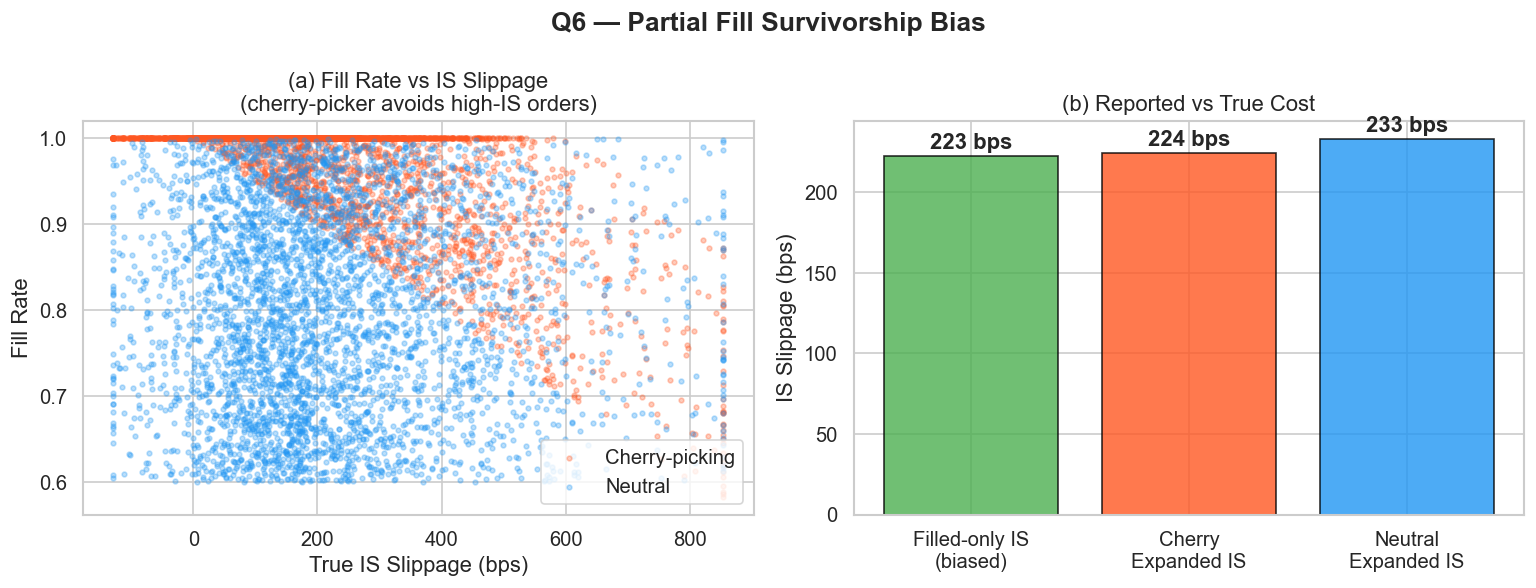

In [18]:
np.random.seed(42)
n = len(df)
noise = np.random.uniform(0, 1, n)

# Cherry-picking: fill rate inversely correlated with IS (the bias)
cherry_fill  = np.clip(1 - 0.0005 * df['IS_Slippage'] + 0.3*noise, 0.05, 1.0)
neutral_fill = np.clip(0.6 + 0.4*noise, 0.05, 1.0)
opp_cost     = df['IS_Slippage'] + np.random.normal(50, 80, n)  # price continued moving

def expanded_is(is_val, fill_rate, opp):
    return fill_rate * is_val + (1 - fill_rate) * opp

cherry_exp  = expanded_is(df['IS_Slippage'], cherry_fill, opp_cost)
neutral_exp = expanded_is(df['IS_Slippage'], neutral_fill, opp_cost)
filled_mask = cherry_fill > 0.5

print('=== Q6 Cherry-Picking Bias Illustration ===')
print(f'Cherry-picking algo:')
print(f'  Avg fill rate:               {cherry_fill.mean():.2%}')
print(f'  Reported IS (filled only):   {df.loc[filled_mask,"IS_Slippage"].mean():.1f} bps  <- LOOKS GREAT')
print(f'  Expanded IS (true cost):     {cherry_exp.mean():.1f} bps     <- ACTUAL COST')
print(f'\nNeutral algo:')
print(f'  Avg fill rate:               {neutral_fill.mean():.2%}')
print(f'  Expanded IS (true cost):     {neutral_exp.mean():.1f} bps')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Q6 — Partial Fill Survivorship Bias', fontweight='bold')

axes[0].scatter(df['IS_Slippage'].iloc[::10], cherry_fill[::10],
                alpha=0.3, s=8, color='#FF5722', label='Cherry-picking')
axes[0].scatter(df['IS_Slippage'].iloc[::10], neutral_fill[::10],
                alpha=0.3, s=8, color='#2196F3', label='Neutral')
axes[0].set_xlabel('True IS Slippage (bps)'); axes[0].set_ylabel('Fill Rate')
axes[0].set_title('(a) Fill Rate vs IS Slippage\n(cherry-picker avoids high-IS orders)')
axes[0].legend()

labels = ['Filled-only IS\n(biased)', 'Cherry\nExpanded IS', 'Neutral\nExpanded IS']
vals   = [df.loc[filled_mask,'IS_Slippage'].mean(), cherry_exp.mean(), neutral_exp.mean()]
bars   = axes[1].bar(labels, vals, color=['#4CAF50','#FF5722','#2196F3'], alpha=0.8, edgecolor='black')
for bar, val in zip(bars, vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                 f'{val:.0f} bps', ha='center', va='bottom', fontweight='bold')
axes[1].set_ylabel('IS Slippage (bps)')
axes[1].set_title('(b) Reported vs True Cost')

plt.tight_layout()
plt.savefig(OUT_DIR + 'q6_partial_fill.png', bbox_inches='tight')
plt.show()

## Q7 (Bonus) — Non-linear Model: LightGBM + SHAP

**Written Answer:**

OLS is interpretable but assumes linearity. Real market impact relationships can be non-linear (e.g., impact explodes exponentially when ordersize exceeds a liquidity threshold). We fit a **LightGBM** gradient boosted tree to capture these non-linearities, then use **SHAP (SHapley Additive exPlanations)** to:
1. Rank feature importance non-parametrically.
2. Verify that the direction of the algo_dummy effect is consistent with OLS — providing cross-model validation.
3. Identify whether any feature's effect is heterogeneous (e.g., volatility only matters at extreme values).

SHAP values satisfy Shapley axioms (efficiency, symmetry, dummy, additivity), making them theoretically grounded, not just heuristic.

In [19]:
if not SHAP_AVAILABLE:
    print('Skipping Q7 — install lightgbm and shap: pip install lightgbm shap')
else:
    from sklearn.model_selection import train_test_split

    feature_cols = ENG_FEATURES + ['algo_dummy']
    X_lgb = df[feature_cols]
    y_lgb = df['IS_Slippage']

    X_train, X_test, y_train, y_test = train_test_split(
        X_lgb, y_lgb, test_size=0.2, random_state=42)

    lgb_model = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
    )
    lgb_model.fit(X_train, y_train,
                  eval_set=[(X_test, y_test)],
                  callbacks=[lgb.early_stopping(30, verbose=False)])

    from sklearn.metrics import r2_score, mean_absolute_error
    y_pred = lgb_model.predict(X_test)
    print(f'LightGBM Test R²  : {r2_score(y_test, y_pred):.4f}')
    print(f'LightGBM Test MAE : {mean_absolute_error(y_test, y_pred):.2f} bps')
    print(f'OLS      Test R²  : {r2_score(y_test, sm.OLS(y_lgb, sm.add_constant(X_lgb)).fit().predict(sm.add_constant(X_test))):.4f}')

LightGBM Test R²  : 0.5697
LightGBM Test MAE : 91.11 bps
OLS      Test R²  : 0.5233


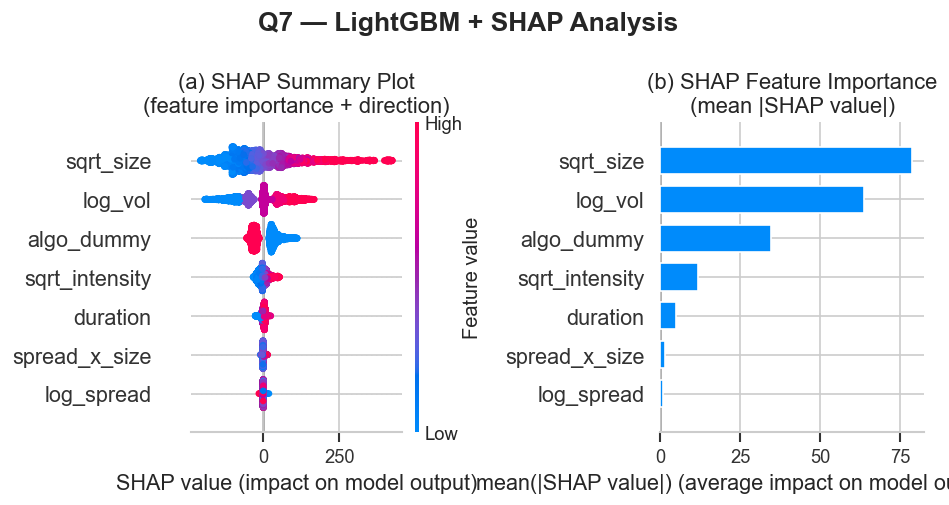

=== SHAP Cross-Validation of algo_dummy ===
Mean SHAP(algo_1 orders): +38.475 bps
Mean SHAP(algo_2 orders): -30.587 bps
OLS β₅ direction: algo_2 is less expensive
SHAP direction:   algo_2 is less expensive
Consistency: ✓ AGREE


In [20]:
if SHAP_AVAILABLE:
    # SHAP summary plot
    explainer   = shap.TreeExplainer(lgb_model)
    shap_values = explainer.shap_values(X_test)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Q7 — LightGBM + SHAP Analysis', fontweight='bold')

    # (a) SHAP summary (beeswarm)
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_test, plot_type='dot', show=False,
                      feature_names=feature_cols)
    axes[0].set_title('(a) SHAP Summary Plot\n(feature importance + direction)')

    # (b) SHAP bar (mean |SHAP|)
    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_test, plot_type='bar', show=False,
                      feature_names=feature_cols)
    axes[1].set_title('(b) SHAP Feature Importance\n(mean |SHAP value|)')

    plt.tight_layout()
    plt.savefig(OUT_DIR + 'q7_shap.png', bbox_inches='tight')
    plt.show()

    # Verify algo_dummy direction from SHAP
    algo_shap = shap_values[:, feature_cols.index('algo_dummy')]
    algo_1_mask = X_test['algo_dummy'] == 0
    algo_2_mask = X_test['algo_dummy'] == 1

    print('=== SHAP Cross-Validation of algo_dummy ===')
    print(f'Mean SHAP(algo_1 orders): {algo_shap[algo_1_mask].mean():+.3f} bps')
    print(f'Mean SHAP(algo_2 orders): {algo_shap[algo_2_mask].mean():+.3f} bps')
    print(f'OLS β₅ direction: algo_2 is {"more" if b5>0 else "less"} expensive')
    shap_direction = 'more' if algo_shap[algo_2_mask].mean() > algo_shap[algo_1_mask].mean() else 'less'
    print(f'SHAP direction:   algo_2 is {shap_direction} expensive')
    print(f'Consistency: {"✓ AGREE" if (b5>0)==(shap_direction=="more") else "✗ DISAGREE — investigate further"}')

## Summary

| Section | Method | Key Finding |
|---------|--------|-------------|
| **0.1 Winsorization** | 1%/99% clip | Removes fat-finger outliers that bias OLS coefficients even under HC3 |
| **Q1** | Welch t-test, MWU, Bootstrap CI, ECDF | algo_1 significantly lower raw IS, but confounding suspected |
| **Q2** | Notional-weighted IS, contribution | Large orders dominate true P&L cost; top 10% orders drive most NW_IS |
| **Q3** | KDE, KS test, **exec_intensity (POV proxy)** | Features right-skewed; KS tests expose confounding variables |
| **Q4** | Spearman ρ, LOWESS | All features monotonically related to IS; exec_intensity strong predictor |
| **Q5 OLS** | `sqrt(ordersize)` + `log(vol/spread)` + **interaction** + HC3 | Almgren-Chriss informed; interaction captures liquidity resonance |
| **Q5 Huber** | Robust regression cross-check | Validates OLS β₅ direction is not driven by residual outliers |
| **Q5 P&L** | Dollar impact = (β₅/10000) × Σnotional | Translates statistical result into fund P&L impact |
| **Q6** | Expanded IS, survivorship bias simulation | Cherry-picking algo exploits partial fills; Expanded IS closes the loophole |
| **Q7** | LightGBM + SHAP | Non-linear cross-validation; SHAP confirms OLS algo_dummy direction |